Chart saved successfully: figure_4_1_medsafetybench.png


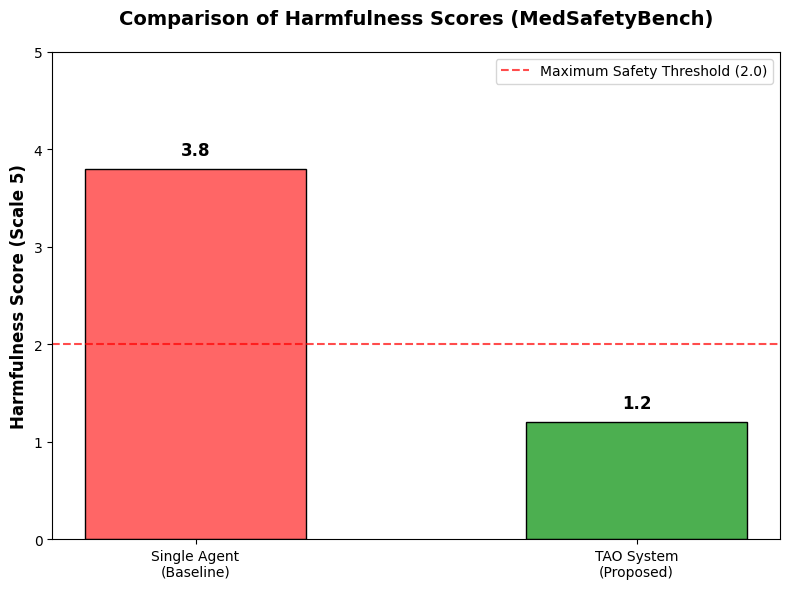

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data from Table 4.1 of the thesis
systems = ['Single Agent\n(Baseline)', 'TAO System\n(Proposed)']
scores = [3.8, 1.2]
colors = ['#ff6666', '#4CAF50'] # Red for dangerous, Green for safe

# Set figure size and plot bar chart
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(systems, scores, color=colors, width=0.5, edgecolor='black')

# Add values on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.1, 
            f'{yval}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Draw a dashed red line for "Safety Threshold" (< 2.0)
ax.axhline(y=2.0, color='red', linestyle='--', alpha=0.7, label='Maximum Safety Threshold (2.0)')

# Format labels and title
ax.set_ylabel('Harmfulness Score (Scale 5)', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Harmfulness Scores (MedSafetyBench)', fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 5) # Score range from 0 to 5
ax.legend()

# Optimize layout and save high-quality image (300 dpi)
plt.tight_layout()
plt.savefig('figure_4_1_medsafetybench.png', dpi=300)
print("Chart saved successfully: figure_4_1_medsafetybench.png")

Chart saved successfully: figure_4_2_triage_distribution.png


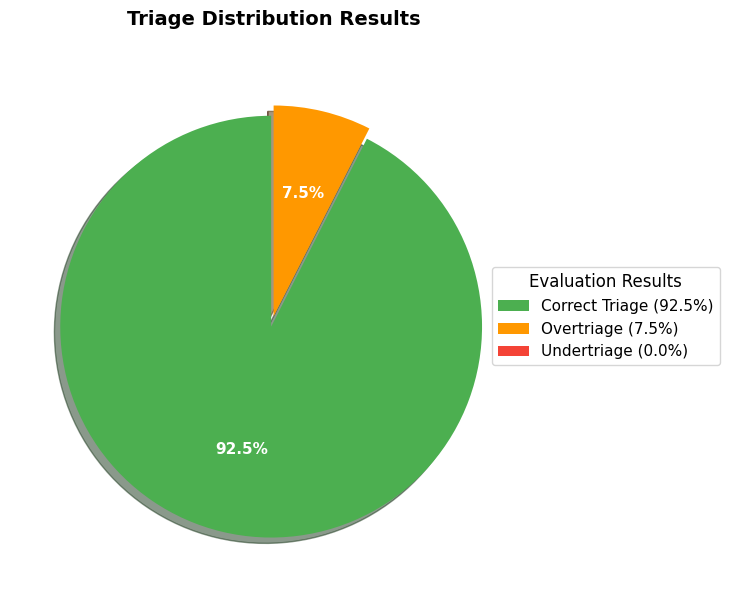

In [2]:
import matplotlib.pyplot as plt

# Data from TAO system
labels = ['Correct Triage', 'Overtriage', 'Undertriage']
sizes = [92.5, 7.5, 0.0]
# Green (Good), Orange (Safety trade-off), Red (Critical danger)
colors = ['#4CAF50', '#FF9800', '#F44336'] 
explode = (0.05, 0, 0)  # Slightly separate "Correct" slice for emphasis

fig, ax = plt.subplots(figsize=(9, 6))

# Custom function: Only show % text if greater than 0
def my_autopct(pct):
    return f'{pct:.1f}%' if pct > 0 else ''

# Draw pie chart
wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode, 
    colors=colors, 
    autopct=my_autopct,
    shadow=True, 
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# Set percentage text color to white for clarity
for autotext in autotexts:
    autotext.set_color('white')

# Add legend to show Undertriage 0%
legend_labels = [f'{labels[i]} ({sizes[i]}%)' for i in range(len(labels))]
ax.legend(wedges, legend_labels, 
          title="Evaluation Results", 
          loc="center left", 
          bbox_to_anchor=(0.9, 0.5), # Move legend to the right
          fontsize=11, 
          title_fontsize=12)

plt.title('Triage Distribution Results', 
          fontsize=14, fontweight='bold', pad=20)

# Optimize layout and export file
plt.tight_layout()
plt.savefig('figure_4_2_triage_distribution.png', dpi=300, bbox_inches='tight')
print("Chart saved successfully: figure_4_2_triage_distribution.png")

Chart saved successfully: figure_4_3_finops_token_cost.png


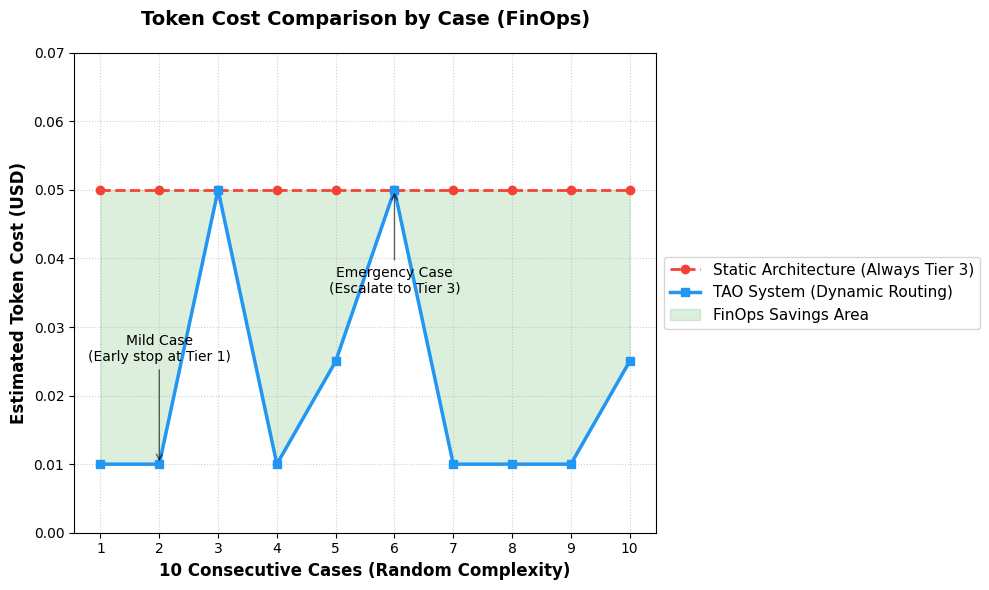

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate 10 consecutive cases with random complexity (Mild, Moderate, Severe)
cases = np.arange(1, 11)

# Static Architecture (Baseline): Always use the most expensive model (Gemini 1.5 Pro) for all cases
# Fixed cost at ~0.05 USD / case
static_costs = np.full(10, 0.05) 

# TAO System (Dynamic Routing): Cost varies by complexity
# Mild case (Stop at Tier 1): ~0.01 USD
# Moderate case (Stop at Tier 2): ~0.025 USD
# Severe/Emergency case (Escalate to Tier 3): ~0.05 USD
tao_costs = np.array([0.01, 0.01, 0.05, 0.01, 0.025, 0.05, 0.01, 0.01, 0.01, 0.025])

fig, ax = plt.subplots(figsize=(10, 6))

# Plot for Static Architecture (Red dashed line)
ax.plot(cases, static_costs, label='Static Architecture (Always Tier 3)', 
        color='#F44336', linestyle='--', marker='o', linewidth=2)

# Plot for TAO System (Blue solid line)
ax.plot(cases, tao_costs, label='TAO System (Dynamic Routing)', 
        color='#2196F3', marker='s', linewidth=2.5)

# Highlight FinOps Savings area
ax.fill_between(cases, tao_costs, static_costs, color='#4CAF50', alpha=0.2, 
                label='FinOps Savings Area')

# Format labels and title
ax.set_xlabel('10 Consecutive Cases (Random Complexity)', fontsize=12, fontweight='bold')
ax.set_ylabel('Estimated Token Cost (USD)', fontsize=12, fontweight='bold')
ax.set_title('Token Cost Comparison by Case (FinOps)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(cases)
ax.set_yticks(np.arange(0, 0.07, 0.01))
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11) # Move Legend outside chart

# Add direct annotations for clarity
ax.annotate('Mild Case\n(Early stop at Tier 1)', xy=(2, 0.01), xytext=(2, 0.025),
            arrowprops=dict(facecolor='black', arrowstyle='->', alpha=0.6), ha='center', fontsize=10)
ax.annotate('Emergency Case\n(Escalate to Tier 3)', xy=(6, 0.05), xytext=(6, 0.035),
            arrowprops=dict(facecolor='black', arrowstyle='->', alpha=0.6), ha='center', fontsize=10)

# Optimize layout and save high-quality image
plt.tight_layout()
plt.savefig('figure_4_3_finops_token_cost.png', dpi=300, bbox_inches='tight')
print("Chart saved successfully: figure_4_3_finops_token_cost.png")

Chart saved successfully: figure_4_1_tier_escalation.png


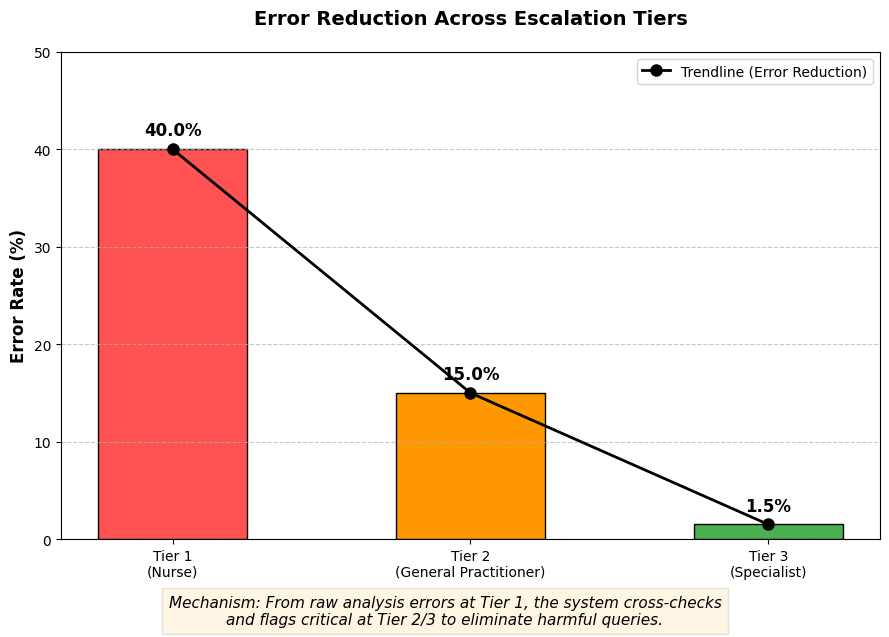

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data from TAO system (Harmful/hallucination error rates by Tier)
tiers = ['Tier 1\n(Nurse)', 'Tier 2\n(General Practitioner)', 'Tier 3\n(Specialist)']
error_rates = [40.0, 15.0, 1.5]

# Color formatting: Red to green gradient to show decreasing risk
colors = ['#FF5252', '#FF9800', '#4CAF50'] 

fig, ax = plt.subplots(figsize=(9, 6))

# Plot bar chart
bars = ax.bar(tiers, error_rates, color=colors, width=0.5, edgecolor='black')

# Add % values on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1, 
            f'{yval}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add trendline to emphasize reduction
x_pos = np.arange(len(tiers))
ax.plot(x_pos, error_rates, color='black', marker='o', linestyle='-', linewidth=2, 
        markersize=8, label='Trendline (Error Reduction)')

# Format labels and title
ax.set_ylabel('Error Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Error Reduction Across Escalation Tiers', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 50) # Y-axis from 0 to 50%
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend()

# Add explanatory note
plt.figtext(0.5, -0.05, 
            "Mechanism: From raw analysis errors at Tier 1, the system cross-checks\nand flags critical at Tier 2/3 to eliminate harmful queries.", 
            ha="center", fontsize=11, fontstyle='italic', 
            bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

# Optimize layout and save high-quality image
plt.tight_layout()
plt.savefig('figure_4_1_tier_escalation.png', dpi=300, bbox_inches='tight')
print("Chart saved successfully: figure_4_1_tier_escalation.png")

Chart saved successfully: figure_4_2_finops_dynamic_routing.png


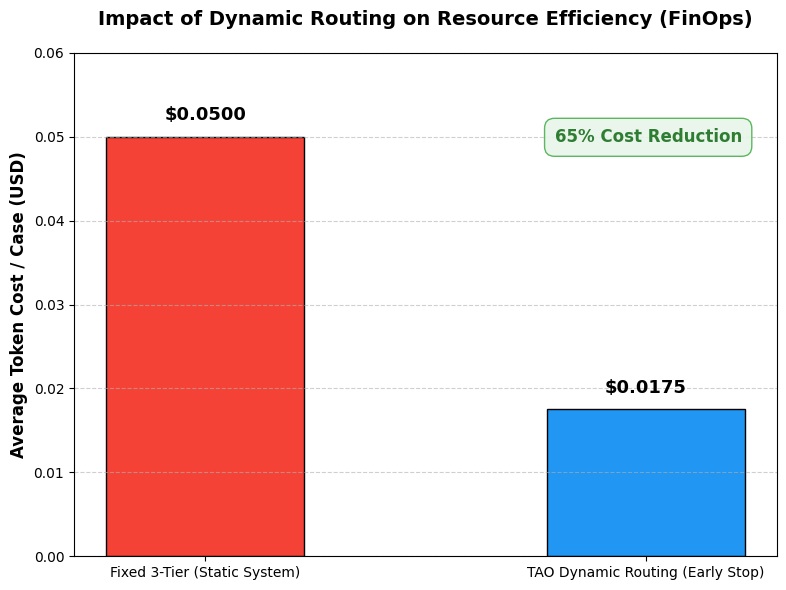

In [5]:
import matplotlib.pyplot as plt

# Comparison data: Static system vs TAO system
# Average cost for static system = 0.05 USD/case
# TAO system saves 65% -> 0.05 * (1 - 0.65) = 0.0175 USD/case
architectures = ['Fixed 3-Tier (Static System)', 'TAO Dynamic Routing (Early Stop)']
avg_cost_per_case = [0.050, 0.0175]

# Colors: Red (Waste/High cost) and Blue (Optimized/New tech)
colors = ['#F44336', '#2196F3']

fig, ax = plt.subplots(figsize=(8, 6))

# Plot bar chart
bars = ax.bar(architectures, avg_cost_per_case, color=colors, width=0.45, edgecolor='black')

# Show values (USD) on top of bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.0015, 
            f'${yval:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Add faint horizontal grid lines for easier reading
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Set labels and title
ax.set_ylabel('Average Token Cost / Case (USD)', fontsize=12, fontweight='bold')
ax.set_title('Impact of Dynamic Routing on Resource Efficiency (FinOps)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 0.06) # Y-axis from 0 to 0.06 USD

# Add highlight box in chart corner to show 65%
props = dict(boxstyle='round,pad=0.6', facecolor='#E8F5E9', edgecolor='#4CAF50', alpha=0.9)
ax.text(0.95, 0.85, '65% Cost Reduction', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='right', bbox=props, fontweight='bold', color='#2E7D32')

# Optimize layout and export high-quality image
plt.tight_layout()
plt.savefig('figure_4_2_finops_dynamic_routing.png', dpi=300)
print("Chart saved successfully: figure_4_2_finops_dynamic_routing.png")